In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from plotly import express as px

In [2]:
data_canada = px.data.gapminder().query("country == 'Canada'")
fig = px.bar(data_canada, x='year', y='pop')

In [3]:
data = pd.read_csv('data/coupons.csv')

In [4]:
data['car'] = data['car'].fillna('')
data['Bar'] = data['Bar'].fillna('')
data['CoffeeHouse'] = data['CoffeeHouse'].fillna('')
data['CarryAway'] = data['CarryAway'].fillna('')
data['RestaurantLessThan20'] = data['RestaurantLessThan20'].fillna('')
data['Restaurant20To50'] = data['Restaurant20To50'].fillna('')

In [5]:
data.isna().sum()

destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
car                     0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Y                       0
dtype: int64

In [6]:
len_data = len(data)
len_data

12684

In [7]:
Y_len  = len(data[data['Y'] == 1])
Y_len

7210

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

Five Different Coupon Types

In [8]:
data['coupon'].unique()

<ArrowStringArray>
[      'Restaurant(<20)',          'Coffee House', 'Carry out & Take away',
                   'Bar',     'Restaurant(20-50)']
Length: 5, dtype: str

In [9]:
coffeedf = data[data['coupon'] == 'Coffee House']
restLowdf = data[data['coupon'] == 'Restaurant(<20)']
rest_20to50_df = data[data['coupon'] == 'Restaurant(20-50)']
bardf = data[data['coupon'] == 'Restaurant(<20)']
carrydf = data[data['coupon'] == 'Carry out & Take away']

In [10]:
def yes_coupon(df):
    return df[df['Y'] == 1]

In [11]:
def ratio_data(df):
    dfy = yes_coupon(df)
    
    ly = len(dfy)
    l = len(df)
    r = len(dfy)/len(df) * 100
    return f" {ly}/{l}  {r}"
    

In [12]:
ratio_data(rest_20to50_df)

' 658/1492  44.10187667560322'

In [13]:
data['age'].unique()

<ArrowStringArray>
['21', '46', '26', '31', '41', '50plus', '36', 'below21']
Length: 8, dtype: str

In [14]:
rest_20to50_kids_df = rest_20to50_df[rest_20to50_df["passanger"] == 'Kid(s)']
ratio_data(rest_20to50_kids_df)

' 65/174  37.35632183908046'

In [15]:
rest_20to50_kids_df = rest_20to50_df[rest_20to50_df["passanger"].isin(["Friend(s)"])] # 69% with Friends
ratio_data(rest_20to50_kids_df)

' 78/168  46.42857142857143'

In [16]:
rest_20to50_kids_df = rest_20to50_df[rest_20to50_df["passanger"].isin(["Partner"])]
ratio_data(rest_20to50_kids_df)

' 89/141  63.12056737588653'

In [17]:
rest_20to50_kids_df = rest_20to50_df[rest_20to50_df["passanger"].isin(["Alone"])]
ratio_data(rest_20to50_kids_df)

' 426/1009  42.22001982160555'

In [18]:
data["passanger"].unique()

<ArrowStringArray>
['Alone', 'Friend(s)', 'Kid(s)', 'Partner']
Length: 4, dtype: str

In [19]:
fifty_plus_df = data[data['age'] == '50plus']
ratio_data(fifty_plus_df)

' 910/1788  50.89485458612975'

In [20]:
fifty_plus_friends_df = fifty_plus_df[fifty_plus_df["passanger"].isin(["Friend(s)"])] # having friends increases by 9 percent!
ratio_data(fifty_plus_friends_df)

' 280/473  59.19661733615222'

In [21]:
fifty_plus_friends_df = fifty_plus_df[fifty_plus_df["passanger"].isin(["Friend(s)"])] # having friends increases by 9 percent!
ratio_data(fifty_plus_friends_df)

' 280/473  59.19661733615222'

In [22]:
twenty_one_df = data[data['age'].isin(["21"])]
ratio_data(twenty_one_df)

' 1587/2653  59.81907274783265'

In [23]:
twenty_one_friends_df = twenty_one_df[twenty_one_df["passanger"].isin(["Friend(s)"])] # having friends increases by 10 percent!
ratio_data(twenty_one_friends_df)

' 513/736  69.70108695652173'

In [24]:
twenty_one_friends_df = twenty_one_df[twenty_one_df["passanger"].isin(["Alone"])] # having friends increases by 10 percent!
ratio_data(twenty_one_friends_df)

' 875/1595  54.858934169278996'

In [25]:
young_df = data[data['age'].isin(["21", "26", "31"])]
ratio_data(young_df)

' 4226/7251  58.281616328782235'

In [26]:
young_friends_df = young_df[young_df["passanger"].isin(["Friend(s)"])] # having friends increases by 11 percent!
ratio_data(young_friends_df)  # young with friends!!

' 1332/1906  69.88457502623295'

In [27]:
young_alone_df = young_df[young_df["passanger"].isin(["Alone"])] # having friends increases by 11 percent!
ratio_data(young_alone_df) 

' 2266/4240  53.443396226415096'

In [28]:
data.coupon.unique()

<ArrowStringArray>
[      'Restaurant(<20)',          'Coffee House', 'Carry out & Take away',
                   'Bar',     'Restaurant(20-50)']
Length: 5, dtype: str

It looks like having friends increases the yes count for coupons

Lets be systematic about this and create some tests
* Compare the locations
* Compare age
* Compare friends vs alone

In [29]:
coffeedf = data[data['coupon'] == 'Coffee House']
rest_LT10df = data[data['coupon'] == 'Restaurant(<20)']
rest_20to50df = data[data['coupon'] == 'Restaurant(20-50)']
bardf = data[data['coupon'] == 'Restaurant(<20)']
carrydf = data[data['coupon'] == 'Carry out & Take away']

moderate frequency


In [30]:
def moderate_frequency(df,coupon):
    return coffeedf[coffeedf[coupon].isin(['4~8', '1~3', 'gt8'])]

In [31]:
def young(df):
    return df[df['age'].isin(["21", "26", "31"])]

In [32]:
def alone(df):
    return df[df["passanger"].isin(["Alone"])]

In [33]:
def friends(df):
    return df[df["passanger"].isin(["Friend(s)"])]

In [34]:
def tenPM(df):
    return df[df['time'] == '10PM']

In [35]:
def twoPM(df):
    return df[df['time'] == '2PM'] 

In [36]:
def sixPM(df):
    return df[df['time'] == '6PM'] 

In [37]:

rest_LT10df = moderate_frequency(restLowdf,"RestaurantLessThan20")
rest_20to50_df = moderate_frequency(rest_20to50_df,"Restaurant20To50")
bardf = moderate_frequency(bardf,"Bar")
carrydf = moderate_frequency(carrydf,"CarryAway")

## Coffee House

In [38]:
coffeemddf = moderate_frequency(coffeedf,"CoffeeHouse")

In [39]:
ratio_data(coffeemddf)

' 1269/1922  66.02497398543184'

In [40]:
def stats(df,coupon):
    print(coupon)
    df = moderate_frequency(df, coupon)
    print(f"Moderate {ratio_data(df)}")
    f = friends(df)
    print(f"Friends {ratio_data(f)}")
    a = alone(df)
    print(f"Alone {ratio_data(a)}")
    y = young(df)
    print(f"Young {ratio_data(y)}")
    
    ya = alone(y)
    print(f"Young  and Alone {ratio_data(ya)}")
    yf = friends(y)
    print(f"Young with Friends {ratio_data(yf)}")
    twodf = twoPM(yf)
    print(f"Two PM {ratio_data(twodf)}")
    sixdf = sixPM(yf)
    print(f"Six PM {ratio_data(sixdf)}")
    tendf = tenPM(yf)
    print(f"Ten PM {ratio_data(tendf)}")

In [41]:
stats(coffeedf,"CoffeeHouse")

CoffeeHouse
Moderate  1269/1922  66.02497398543184
Friends  461/604  76.32450331125827
Alone  643/1089  59.04499540863177
Young  760/1139  66.72519754170325
Young  and Alone  378/640  59.06249999999999
Young with Friends  284/370  76.75675675675676
Two PM  153/199  76.88442211055276
Six PM  32/50  64.0
Ten PM  21/32  65.625


In [42]:
stats(rest_LT10df,"RestaurantLessThan20")

RestaurantLessThan20
Moderate  1649/3245  50.81664098613251
Friends  604/989  61.071789686552066
Alone  810/1825  44.38356164383562
Young  985/1886  52.226935312831394
Young  and Alone  473/1068  44.28838951310862
Young with Friends  373/581  64.19965576592082
Two PM  194/304  63.81578947368421
Six PM  46/79  58.22784810126582
Ten PM  35/51  68.62745098039215


In [43]:
stats(rest_20to50df,"Restaurant20To50")

Restaurant20To50
Moderate  719/1350  53.25925925925926
Friends  263/406  64.77832512315271
Alone  339/751  45.13981358189081
Young  434/819  52.991452991452995
Young  and Alone  210/453  46.35761589403973
Young with Friends  161/253  63.63636363636363
Two PM  82/131  62.59541984732825
Six PM  19/34  55.88235294117647
Ten PM  19/25  76.0


In [44]:
stats(bardf,"Bar")

Bar
Moderate  625/1245  50.20080321285141
Friends  244/406  60.09852216748769
Alone  313/708  44.2090395480226
Young  461/925  49.83783783783784
Young  and Alone  232/533  43.52720450281426
Young with Friends  186/308  60.3896103896104
Two PM  101/165  61.212121212121204
Six PM  25/49  51.02040816326531
Ten PM  12/20  60.0


In [45]:
stats(carrydf,"CarryAway")

CarryAway
Moderate  1698/3322  51.11378687537628
Friends  633/1037  61.041465766634516
Alone  848/1869  45.37185660781166
Young  1051/2029  51.79891572203056
Young  and Alone  511/1139  44.863915715539946
Young with Friends  403/644  62.577639751552795
Two PM  206/340  60.588235294117645
Six PM  48/86  55.81395348837209
Ten PM  38/55  69.0909090909091


# Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

1. Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. 

1. Would you accept that coupon and take a short detour to the restaurant? 

1. Would you accept the coupon but use it on a subsequent trip? 

1. Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? 

1. What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? 

1. What about if it was just you and your partner in the car? 
    
1. Would weather impact the rate of acceptance? What about the time of day?

1. Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not,

    * but what are the factors that determine whether a driver accepts the coupon once it is delivered to them?

1.. How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. 
The survey describes different driving scenarios including the 
1. destination,
2. current time,
3. weather,
4. passenger, etc.,


1. and then ask the person whether he will accept the coupon if he is the driver.
2. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’
3. and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.

1. There are five different types of coupons --
   1. less expensive restaurants (under \$20),
   2. coffee houses,
   3. carry out & take away,
   4. bar, and
   5. more expensive restaurants (\$20 - $50).

In [46]:
data.columns

Index(['destination', 'passanger', 'weather', 'temperature', 'time', 'coupon',
       'expiration', 'gender', 'age', 'maritalStatus', 'has_children',
       'education', 'occupation', 'income', 'car', 'Bar', 'CoffeeHouse',
       'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50',
       'toCoupon_GEQ5min', 'toCoupon_GEQ15min', 'toCoupon_GEQ25min',
       'direction_same', 'direction_opp', 'Y'],
      dtype='str')

In [47]:
df = data

In [48]:
for col in df.columns:
    df[col] = df[col].astype('category')

In [49]:
def crosstab_plot(df,cols, image_name):
    crosstabs = []

    for col in cols:
        ct = pd.crosstab(df[col], df['Y'])
        crosstabs.append(ct)
    pivot = pd.concat(crosstabs)
   
    sns.heatmap(pivot, annot=True, fmt='d', cmap='Blues', linewidths=0.5)
    plt.title('Category vs Y')
    plt.savefig(f"images/{image_name}.png")
    plt.show()

### Acceptance increases on Sunny Days

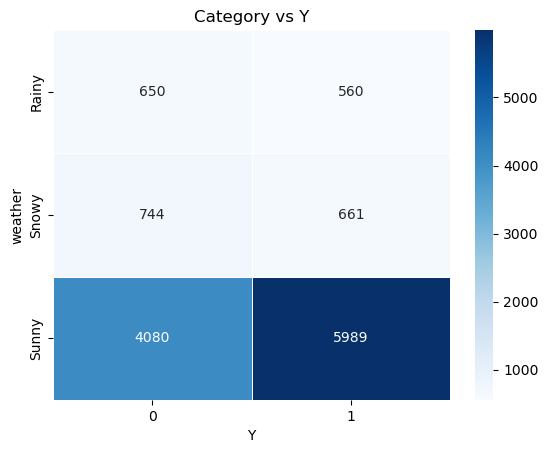

In [50]:
crosstab_plot(df,["weather"], "weather_cross")


## Acceptance increases on warm 80 degree days

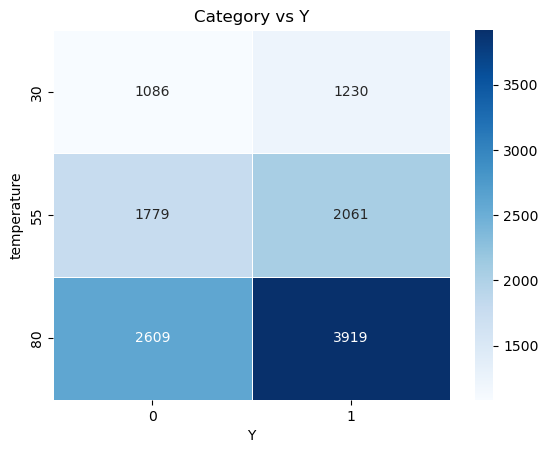

In [51]:
crosstab_plot(df,["temperature"], "temperature_cross")


#### This is counter intuitive, but it appears people accept coupons when going the opposite direction

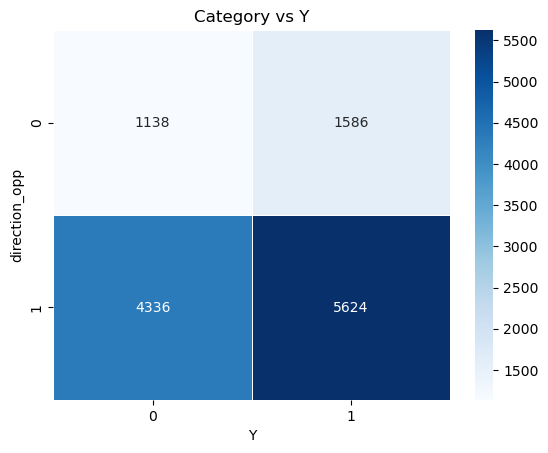

In [52]:
crosstab_plot(df,["direction_opp"], "direction_opp_cross")

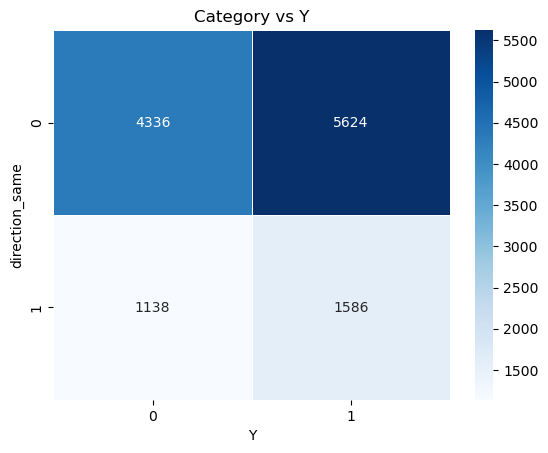

In [53]:
crosstab_plot(df,["direction_same"], "direction_same_cross")

### Combination

In [54]:
data['Y'] = data['Y'].astype(int)

In [55]:
# group by combination of weather and temperature, taking the mean of 'Y' values (0,1)
grouped = data.groupby(["weather",'temperature'])['Y'].mean().reset_index()
grouped

,weather,temperature,Y
0,Rainy,55,0.462810
1,Snowy,30,0.470463
2,Sunny,30,0.624588
3,Sunny,55,0.570722
4,Sunny,80,0.600337


In [56]:
filtered_grouped = grouped[grouped["Y"] == 1] # filter by 'Y' == 1

In [57]:
# count the number of unique combinations where 'Y' == 1
score_1_combination = df.loc[df["Y"] == 1, [ "weather",'temperature' ]].value_counts().reset_index()
# set the columns after reseting the index
score_1_combination.columns=  ['weather','temperature', "Y"]


#### Clearly coupon acceptance is better on Sunny Days, and Best when it is a warm 80 degree day

In [58]:
score_1_combination

,weather,temperature,Y
0,Sunny,80,3919
1,Sunny,55,1501
2,Snowy,30,661
3,Sunny,30,569
4,Rainy,55,560
5,Rainy,80,0
6,Rainy,30,0
7,Snowy,55,0
8,Snowy,80,0
